# WSN Routing & Data Accumulation Simulation
This notebook simulates four key algorithms derived from the research papers on Mobile Sink path selection, Rendezvous Points (RPs), and Visiting Points (VPs).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.cluster import MeanShift
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Global Parameters Setup
class Config:
    NUM_NODES = 1000              # Number of sensor nodes (Updated per request)
    AREA_SIZE = 600               # Deployment area size (600x600m)
    BASE_STATION = (0, 0)         # Base station location
    R_TRANS = 40                  # Transmission range in meters
    BANDWIDTH_MSC = 0.15          # Bandwidth for Mean-Shift Clustering
    MS_SPEED = 2                  # Speed of Mobile Sink (m/s)
    
    # Initialize random network
    np.random.seed(42)
    node_coords = np.random.uniform(0, AREA_SIZE, size=(NUM_NODES, 2))
    node_loads = np.random.randint(1, 10, size=NUM_NODES) # Random data load packets
    
    # Adjacency and Distance Matrices
    dist_matrix = cdist(node_coords, node_coords)
    adj_matrix = (dist_matrix <= R_TRANS)
    np.fill_diagonal(adj_matrix, False)

In [3]:
def algo_1_forwarding_nodes(coords, dist_matrix, adj_matrix, loads):
    """
    Algorithm 1: Selects forwarding nodes (probable RPs) based on neighbor data weights.
    """
    n = len(coords)
    forwarding_nodes = []
    routes = []
    
    for i in range(n):
        neighbors = np.where(adj_matrix[i])[0]
        if len(neighbors) == 0:
            forwarding_nodes.append(i)
            continue
            
        # Compare local load with neighbors
        max_neighbor = neighbors[np.argmax(loads[neighbors])]
        if loads[i] < loads[max_neighbor]:
            forwarding_nodes.append(max_neighbor)
            routes.append((i, max_neighbor))
        else:
            # If current node has max load, check 2-hop
            two_hop_neighbors = np.where(adj_matrix[max_neighbor])[0]
            if len(two_hop_neighbors) > 0:
                best_2hop = two_hop_neighbors[np.argmax(loads[two_hop_neighbors])]
                forwarding_nodes.append(best_2hop)
                routes.append((i, best_2hop))
            else:
                forwarding_nodes.append(max_neighbor)
                routes.append((i, max_neighbor))
                
    fn_unique = list(set(forwarding_nodes))
    
    # Save to CSV
    df = pd.DataFrame({'Node_ID': range(n), 'X': coords[:,0], 'Y': coords[:,1], 'Assigned_FN': forwarding_nodes})
    df.to_csv('algo_simulation_1.csv', index=False)
    
    return fn_unique, routes

In [4]:
def algo_2_mopso_rps(coords, forwarding_nodes, base_station):
    """
    Algorithm 2: Simulates MOPSO for Rendezvous Point (RP) selection and trajectory formation.
    """
    # Simulate MOPSO selecting optimal subset (e.g., top 15% nodes based on centrality/dispersion)
    num_rps = max(5, int(len(forwarding_nodes) * 0.15))
    rps = np.random.choice(forwarding_nodes, num_rps, replace=False)
    
    # MS Trajectory Formation using improved distance heuristic
    unvisited = list(rps)
    current_pos = base_station
    path = []
    
    while unvisited:
        # Distance heuristic considering distance to next RP + distance to BS
        next_node = min(unvisited, key=lambda node: 
                        np.linalg.norm(coords[node] - current_pos) + 
                        np.linalg.norm(coords[node] - base_station))
        path.append(next_node)
        current_pos = coords[next_node]
        unvisited.remove(next_node)
        
    df = pd.DataFrame({'RP_Order': range(1, len(path)+1), 'RP_Node_ID': path, 
                       'X': coords[path, 0], 'Y': coords[path, 1]})
    df.to_csv('algo_simulation_2.csv', index=False)
    
    return rps, path

In [5]:
def algo_3_mean_shift_vps(coords, bandwidth):
    """
    Algorithm 3: Applies Mean-Shift Clustering to determine Visiting Points (VPs).
    """
    ms = MeanShift(bandwidth=bandwidth * Config.AREA_SIZE, bin_seeding=True)
    ms.fit(coords)
    
    cluster_centers = ms.cluster_centers_
    labels = ms.labels_
    
    # Map cluster centers to nearest actual nodes to act as VPs
    vps = []
    for center in cluster_centers:
        closest_node = np.argmin(cdist([center], coords)[0])
        if closest_node not in vps:
            vps.append(closest_node)
            
    df = pd.DataFrame({'Node_ID': range(len(coords)), 'Cluster_Label': labels, 
                       'Is_VP': [1 if i in vps else 0 for i in range(len(coords))]})
    df.to_csv('algo_simulation_3.csv', index=False)
    
    return vps, labels

In [6]:
def algo_4_visiting_order(coords, vps, base_station):
    """
    Algorithm 4: Constructs a Hamiltonian path based on geometric weight estimation.
    """
    nodes = list(vps)
    all_points = np.vstack([coords[nodes], [base_station]])
    bs_idx = len(nodes)
    
    dist_mat = cdist(all_points, all_points)
    weights = np.zeros_like(dist_mat)
    np.divide(1.0, dist_mat, out=weights, where=dist_mat!=0) 
    
    path = [bs_idx] 
    unvisited = set(range(len(nodes)))
    
    while unvisited:
        current = path[-1]
        best_next = None
        best_weight = -1
        
        for candidate in unvisited:
            if weights[current, candidate] > best_weight:
                best_weight = weights[current, candidate]
                best_next = candidate
                
        path.append(best_next)
        unvisited.remove(best_next)
        
    path.append(bs_idx)
    final_path = [nodes[i] if i != bs_idx else -1 for i in path]
    
    df = pd.DataFrame({'Path_Step': range(len(final_path)), 'Node_ID': final_path})
    df.to_csv('algo_simulation_4.csv', index=False)
    
    return final_path

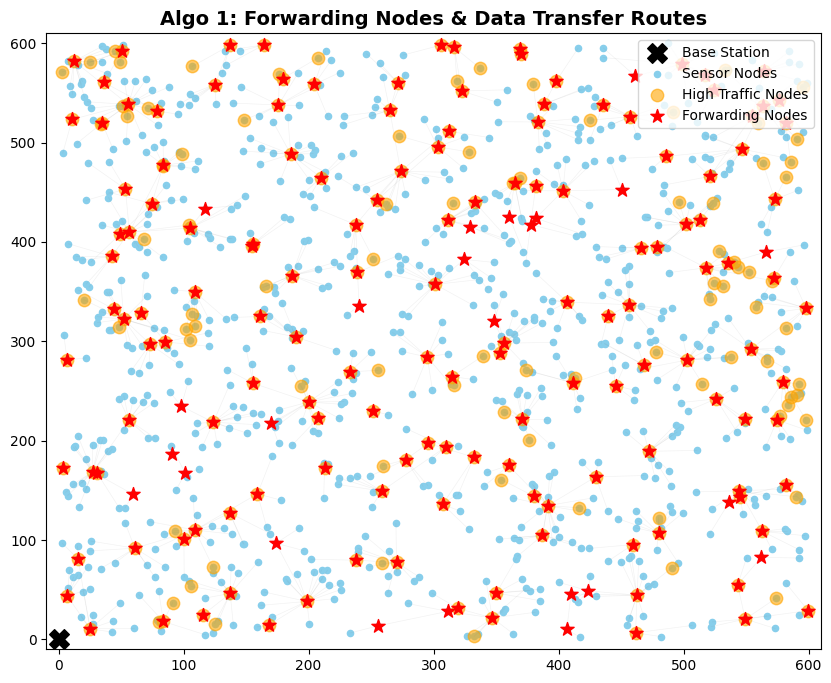

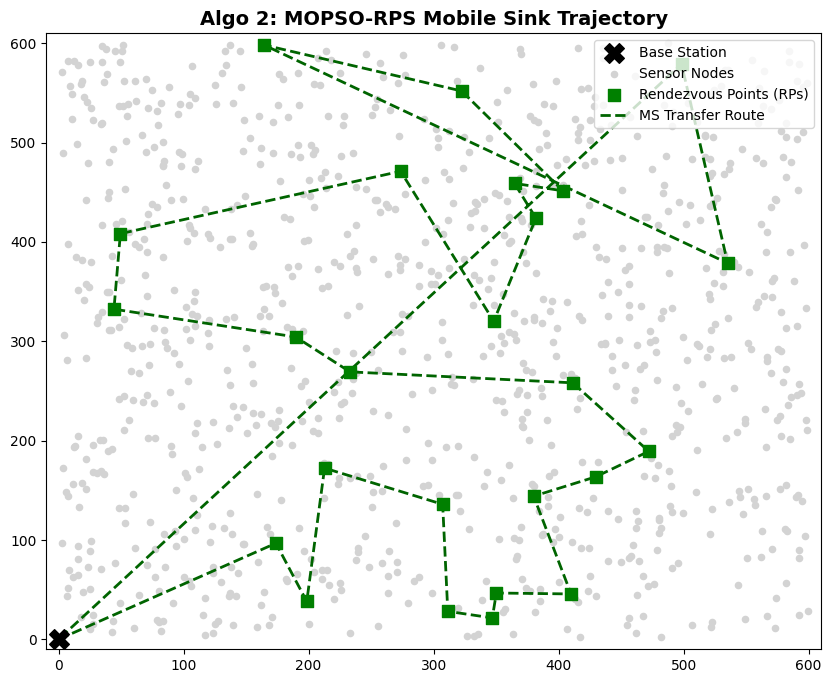

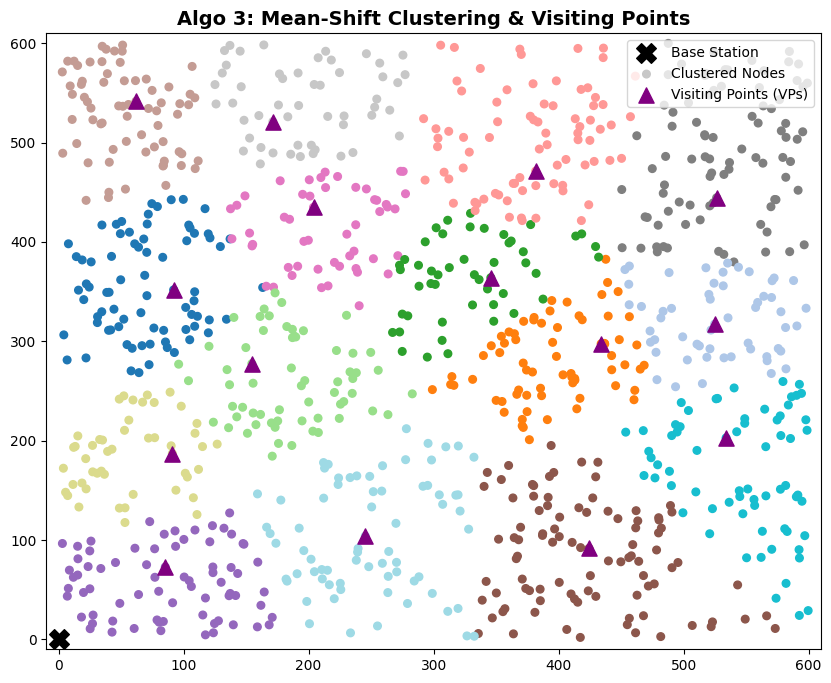

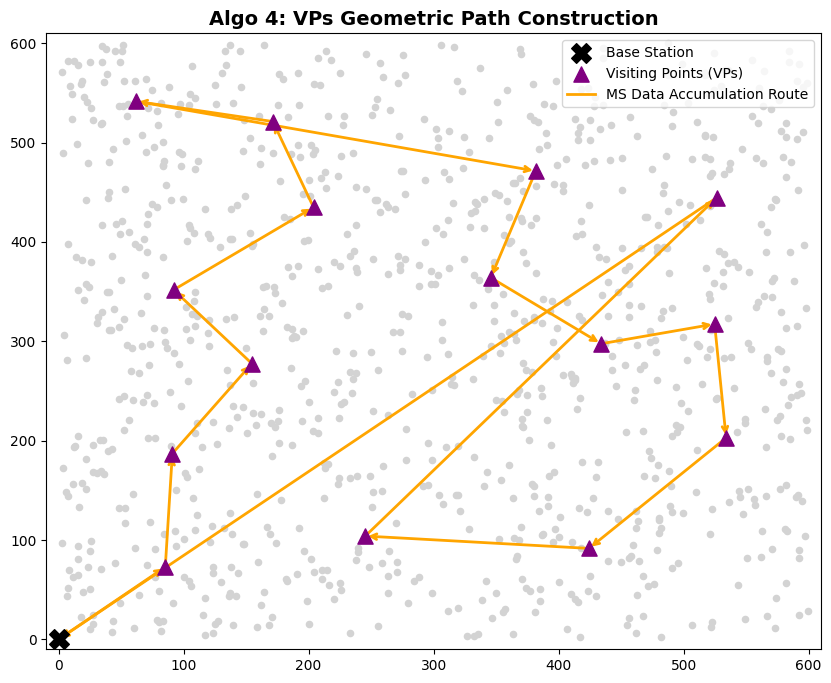

In [7]:
# Execution & Plotting
coords = Config.node_coords
dist_matrix = Config.dist_matrix
adj_matrix = Config.adj_matrix
loads = Config.node_loads
bs = Config.BASE_STATION

# Run Algorithms
fn_unique, routes_algo1 = algo_1_forwarding_nodes(coords, dist_matrix, adj_matrix, loads)
rps_algo2, path_algo2 = algo_2_mopso_rps(coords, fn_unique, bs)
vps_algo3, labels_algo3 = algo_3_mean_shift_vps(coords, Config.BANDWIDTH_MSC)
path_algo4 = algo_4_visiting_order(coords, vps_algo3, bs)

# Setup Plotting Utility
def create_base_plot(title):
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(-10, Config.AREA_SIZE + 10)
    ax.set_ylim(-10, Config.AREA_SIZE + 10)
    ax.scatter(bs[0], bs[1], c='black', marker='X', s=200, label='Base Station', zorder=5)
    return fig, ax

# Plot 1
fig1, ax1 = create_base_plot("Algo 1: Forwarding Nodes & Data Transfer Routes")
high_traffic = np.where(loads >= np.percentile(loads, 80))[0]
ax1.scatter(coords[:,0], coords[:,1], c='skyblue', label='Sensor Nodes', s=20)
ax1.scatter(coords[high_traffic, 0], coords[high_traffic, 1], c='orange', s=80, label='High Traffic Nodes', alpha=0.6)
ax1.scatter(coords[fn_unique, 0], coords[fn_unique, 1], c='red', marker='*', s=100, label='Forwarding Nodes', zorder=4)
for u, v in routes_algo1:
    ax1.plot([coords[u,0], coords[v,0]], [coords[u,1], coords[v,1]], c='gray', alpha=0.1, linewidth=0.5)
ax1.legend(loc='upper right')
fig1.savefig('algo_simulation_1.png', dpi=300, bbox_inches='tight')

# Plot 2
fig2, ax2 = create_base_plot("Algo 2: MOPSO-RPS Mobile Sink Trajectory")
ax2.scatter(coords[:,0], coords[:,1], c='lightgray', s=20, label='Sensor Nodes')
ax2.scatter(coords[rps_algo2, 0], coords[rps_algo2, 1], c='green', marker='s', s=80, label='Rendezvous Points (RPs)', zorder=4)
path_coords = np.vstack([bs, coords[path_algo2], bs])
ax2.plot(path_coords[:,0], path_coords[:,1], c='darkgreen', linestyle='--', linewidth=2, label='MS Transfer Route')
ax2.legend(loc='upper right')
fig2.savefig('algo_simulation_2.png', dpi=300, bbox_inches='tight')

# Plot 3
fig3, ax3 = create_base_plot("Algo 3: Mean-Shift Clustering & Visiting Points")
scatter = ax3.scatter(coords[:,0], coords[:,1], c=labels_algo3, cmap='tab20', s=30, label='Clustered Nodes')
ax3.scatter(coords[vps_algo3, 0], coords[vps_algo3, 1], c='purple', marker='^', s=120, label='Visiting Points (VPs)', zorder=4)
ax3.legend(loc='upper right')
fig3.savefig('algo_simulation_3.png', dpi=300, bbox_inches='tight')

# Plot 4
fig4, ax4 = create_base_plot("Algo 4: VPs Geometric Path Construction")
ax4.scatter(coords[:,0], coords[:,1], c='lightgray', s=20)
ax4.scatter(coords[vps_algo3, 0], coords[vps_algo3, 1], c='purple', marker='^', s=120, label='Visiting Points (VPs)', zorder=4)
path_algo4_coords = np.array([bs if i == -1 else coords[i] for i in path_algo4])
for i in range(len(path_algo4_coords)-1):
    start, end = path_algo4_coords[i], path_algo4_coords[i+1]
    ax4.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", color="orange", lw=2))
ax4.plot([], [], color="orange", lw=2, label="MS Data Accumulation Route")
ax4.legend(loc='upper right')
fig4.savefig('algo_simulation_4.png', dpi=300, bbox_inches='tight')

plt.show()